In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import import_ipynb
import genetic_algorithm
import NSGA2
import simulated_annealing
import BPSO

from evaluators.knn_evaluator import evaluate_all_features_knn, evaluate_selected_features_knn, evaluate_on_test_knn
from evaluators.random_forest_evaluator import evaluate_all_features_rf, evaluate_selected_features_rf, evaluate_on_test_rf
from evaluators.svc_evaluator import evaluate_svc

**Loading dataset: Oral toxicity**

In [4]:
X_train_toxicity = pd.read_csv("../datasets/oral_toxicity/X_train.csv")
y_train_toxicity = pd.read_csv('../datasets/oral_toxicity/y_train.csv').to_numpy().ravel()
X_test_toxicity = pd.read_csv("../datasets/oral_toxicity/X_test.csv")
y_test_toxicity = pd.read_csv("../datasets/oral_toxicity/y_test.csv").to_numpy().ravel()

In [5]:
avg_acc_train, acc_test = evaluate_all_features_knn(X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Average train accuracy: {avg_acc_train:.4f}\nTest accuracy: {acc_test:.4f}")

Average train accuracy: 0.9310
Test accuracy: 0.9314


**Loading dataset: Leukemia**

In [6]:
X_train_leukemia = pd.read_csv("../datasets/leukemia/X_train.csv")
y_train_leukemia = pd.read_csv("../datasets/leukemia/y_train.csv").to_numpy().ravel()
X_test_leukemia = pd.read_csv("../datasets/leukemia/X_test.csv")
y_test_leukemia = pd.read_csv("../datasets/leukemia/y_test.csv").to_numpy().ravel()

In [7]:
avg_acc_train, acc_test = evaluate_all_features_knn(X_train_leukemia, y_train_leukemia, X_test_leukemia, y_test_leukemia)
print(f"Average train accuracy: {avg_acc_train:.4f}\nTest accuracy: {acc_test:.4f}")

Average train accuracy: 0.7000
Test accuracy: 0.8636


**Loading dataset: Ionosphere**

In [8]:
X_train_ionosphere = pd.read_csv("../datasets/ionosphere/X_train.csv")
y_train_ionosphere = pd.read_csv('../datasets/ionosphere/y_train.csv').to_numpy().ravel()
X_test_ionosphere = pd.read_csv("../datasets/ionosphere/X_test.csv")
y_test_ionosphere = pd.read_csv("../datasets/ionosphere/y_test.csv").to_numpy().ravel()

In [9]:
avg_acc_train, acc_test = evaluate_all_features_knn(X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Average train accuracy (KNN): {avg_acc_train:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Average train accuracy (KNN): 0.8327
Test accuracy (KNN): 0.8396


In [10]:
avg_acc_train, acc_test = evaluate_all_features_rf(X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Average train accuracy (RF): {avg_acc_train:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Average train accuracy (RF): 0.9469
Test accuracy (RF): 0.9151


accuracy: 0.9387755102040817 features percentage: 0.20588235294117646
accuracy: 0.9306122448979591 features percentage: 0.14705882352941177
accuracy: 0.9510204081632653 features percentage: 0.23529411764705882
accuracy: 0.9061224489795918 features percentage: 0.08823529411764706
accuracy: 0.9183673469387756 features percentage: 0.11764705882352941


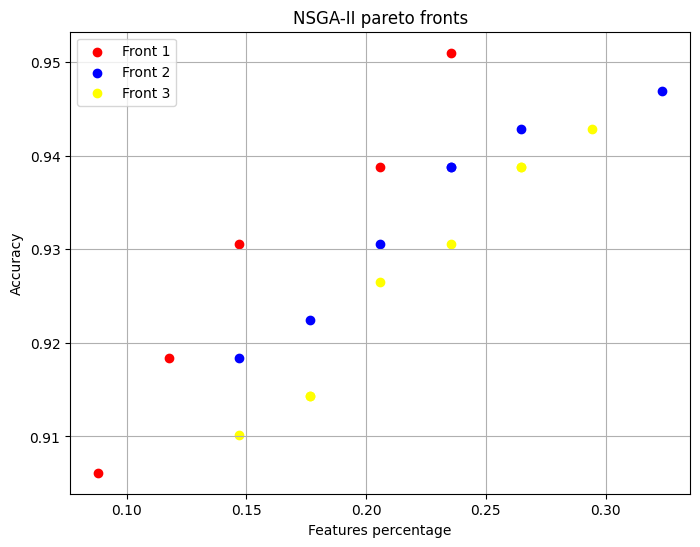

In [11]:
nsga = NSGA2.NSGA2(X_train_ionosphere, y_train_ionosphere, calc_accuracy_fn=evaluate_selected_features_rf,
                   population_size=20, num_generations=20, feature_probability=0.5,mutation_probability=0.1,
                   use_adaptive_mutatation=True)
pareto, fig = nsga.run()
fig.savefig("../images/ds1_NSGA2_fronts.png", dpi = 300)

In [12]:
number_selected_features = [int(sum(i.code)) for i in pareto]
print(f"Number selected features in Pareto front: {number_selected_features}")

Number selected features in Pareto front: [7, 5, 8, 3, 4]


In [13]:
acc_test = evaluate_on_test_rf(pareto[0].code, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Test accuracy (RF): {acc_test:.4f}")

Test accuracy (RF): 0.8868


In [14]:
ga_ionosphere = genetic_algorithm.GA( X_train_ionosphere ,y_train_ionosphere ,calc_accuracy_fn= evaluate_selected_features_rf,
                          population_size = 20, num_generations = 50, tournament_size=4, selection_method = "tournament" ,
                          mutation_probability = 0.1,alpha = 0.5,elitism_size = 3,patience = 10,use_heuristic = False
                          ,initial_feature_percentage = 0.5,use_adaptive_mutatation=True)
best_solution,best_train_accuracy,number_selected_features, best_fitness, history = ga_ionosphere.run()

Generation: 0 best fitnes: 0.7765906362545018
Generation: 1 best fitnes: 0.7827130852340936
Generation: 2 best fitnes: 0.8129651860744297
Generation: 3 best fitnes: 0.8186674669867948
Generation: 4 best fitnes: 0.8521608643457383
Generation: 5 best fitnes: 0.8521608643457383
Generation: 6 best fitnes: 0.854201680672269
Generation: 7 best fitnes: 0.8627851140456182
Generation: 8 best fitnes: 0.8648259303721488
Generation: 9 best fitnes: 0.8648259303721488
Generation: 10 best fitnes: 0.8729891956782712
Generation: 11 best fitnes: 0.8815726290516206
Generation: 12 best fitnes: 0.8815726290516206
Generation: 13 best fitnes: 0.8815726290516206
Generation: 14 best fitnes: 0.8815726290516206
Generation: 15 best fitnes: 0.8815726290516206
Generation: 16 best fitnes: 0.8946578631452581
Generation: 17 best fitnes: 0.8946578631452581
Generation: 18 best fitnes: 0.8946578631452581
Generation: 19 best fitnes: 0.8946578631452581
Generation: 20 best fitnes: 0.9007803121248499
Generation: 21 best fitn

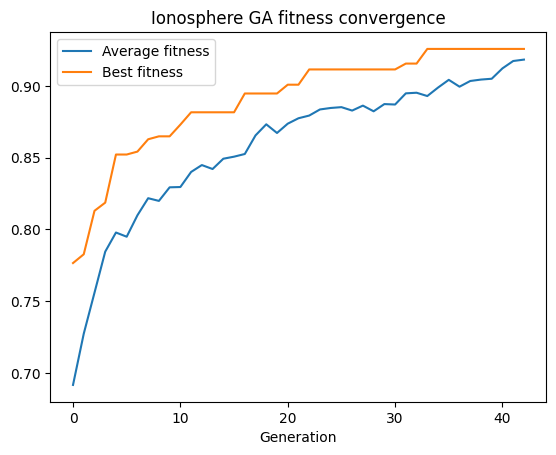

In [15]:
df_history = pd.DataFrame(history,columns = ["Generation","Average fitness","Best fitness"])
plot = df_history.plot(x="Generation", y = ["Average fitness","Best fitness"])
plot.set_title("Ionosphere GA fitness convergence")
plt.savefig("../images/ds1_GA_fc.png", dpi = 300)

In [16]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 2
Feature percentage: 0.0588


In [17]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_accuracy:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.9143
Test accuracy (RF): 0.8868


In [18]:
ga_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 30,
                 code = best_solution,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_ionosphere,
                 y_train = y_train_ionosphere,
                 calc_accuracy_fn = evaluate_selected_features_rf,
                 patience = 30)

In [19]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = ga_sa_extended.run()

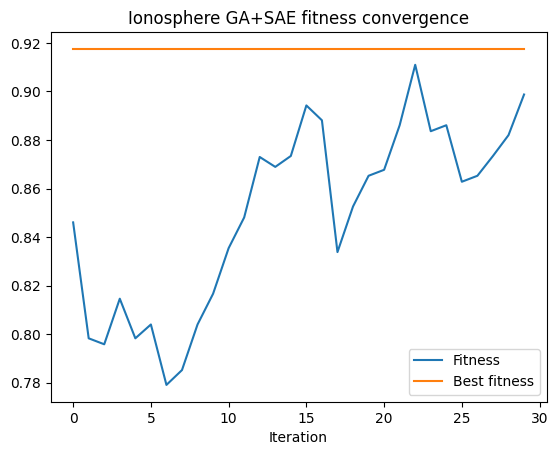

In [20]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Ionosphere GA+SAE fitness convergence")
plt.savefig("../images/ds1_GA+SAE_fc.png", dpi = 300)

In [21]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 2
Feature percentage: 0.0588


In [22]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.9143
Test accuracy (RF): 0.8585


In [23]:
best_position, best_train_acc, number_selected_features, best_fitness, best_history, average_history = BPSO.run(
    X_train = X_train_ionosphere,
    y_train = y_train_ionosphere,
    calc_accuracy_fn = evaluate_selected_features_rf,
    alpha = 0.5,
    num_iters = 50,
    swarm_size = 40,
    c_inertia_start = 1.1,
    c_inertia_end = 0.4,
    c_social = 1.0,
    c_cognitive = 2.0
)

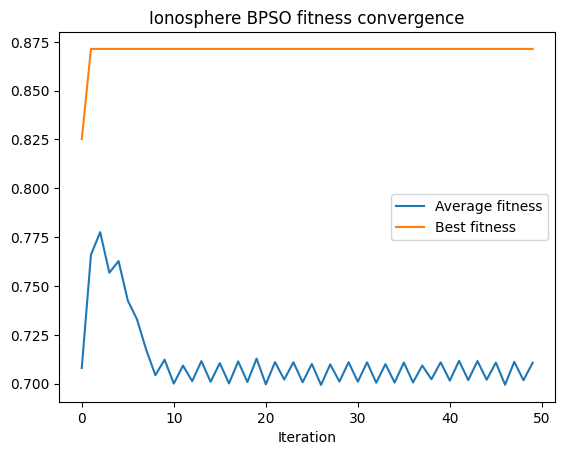

In [24]:
df_avg = pd.DataFrame(average_history, columns=["Iteration", "Average fitness"])
df_best = pd.DataFrame(best_history, columns=["Iteration", "Best fitness"])
df_history = pd.merge(df_avg, df_best, on="Iteration")

plot = df_history.plot(x="Iteration", y = ["Average fitness","Best fitness"])
plot.set_title("Ionosphere BPSO fitness convergence")
plt.savefig("../images/ds1_BPSO_fc.png", dpi = 300)

In [25]:
pct_sel_features = number_selected_features/len(best_position)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 5
Feature percentage: 0.1471


In [26]:
acc_test = evaluate_on_test_rf(best_position, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.8776
Test accuracy (RF): 0.8962


In [27]:
bpso_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 30,
                 code = best_position,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_ionosphere,
                 y_train = y_train_ionosphere,
                 calc_accuracy_fn = evaluate_selected_features_rf,
                 patience = 30)

In [28]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = bpso_sa_extended.run()

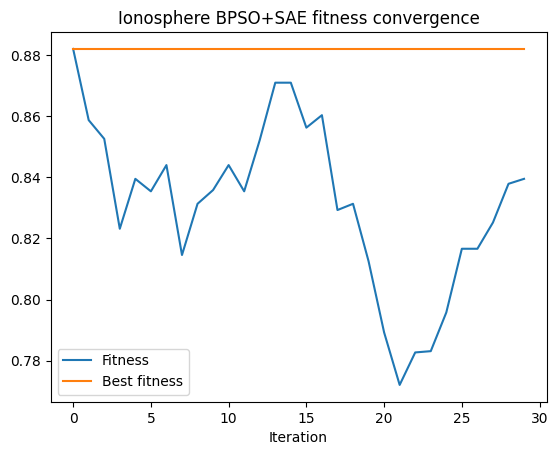

In [29]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Ionosphere BPSO+SAE fitness convergence")
plt.savefig("../images/ds1_BPSO+SAE_fc.png", dpi = 300)

In [30]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 4
Feature percentage: 0.1176


In [31]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.8857
Test accuracy (RF): 0.8774


In [32]:
def generate_code(X_train,percentage):
    return (np.random.rand(X_train.shape[1]) < percentage)

In [33]:
initial_code = generate_code(X_train_ionosphere,0.5)

In [34]:
sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 100,
                 code = initial_code,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_ionosphere,
                 y_train = y_train_ionosphere,
                 calc_accuracy_fn = evaluate_selected_features_rf,
                 patience = 30)

In [35]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = sa_extended.run()

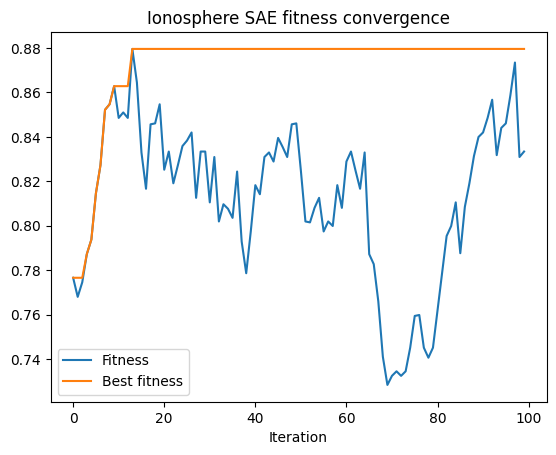

In [36]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Ionosphere SAE fitness convergence")
plt.savefig("../images/ds1_SAE_fc.png", dpi = 300)

In [37]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 5
Feature percentage: 0.1471


In [38]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.8816
Test accuracy (RF): 0.8774
